# {Final Project Climate Change}📝

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

### The topic I'm trying to address is climate change.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

### How do emissions relate to climate change trends?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

### Emissions relate to climate change trends because greenhouse gases, mainly carbon dioxide from burning fossil fuels, deforestation, and agriculture, act as a heat trapping blanket, which directly causes global warming and climate change.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->
For this project, I will be using data from the following data sources

- 1. https://ourworldindata.org/co2-and-greenhouse-gas-emissions#explore-data-on-co2-and-greenhouse-gas-emissions
- 2. https://databank.worldbank.org/source/world-development-indicators
- 3. The following datasets from Kaggle
        - a.https://www.kaggle.com/datasets/ashishraut64/global-methane-emissions
        - b.https://www.kaggle.com/datasets/ravindrasinghrana/carbon-co2-emissions
        - c.https://www.kaggle.com/datasets/willianoliveiragibin/greenhouse-gas-emissions

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

My approach is to combine emissions data from multiple datasets and analyze trends over time. I will clean and merge the datasets using common variables such as country and year. The data will be stored and queried using a SQLite database. I will then create visualizations, such as line charts, to observe how emissions change over time and compare patterns across countries. This analysis will help determine how emissions relate to climate change trends.

In [625]:
# Import necessary libraries for data manipulation and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from pandas.plotting import scatter_matrix
from mpl_toolkits.mplot3d import Axes3D
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error


In [626]:
# Import the data from Our World in Data and store it in a DataFrame.

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

df.sample(5)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
24131,Kazakhstan,1989,KAZ,16997012.0,1.976693e+11,1.211,0.071,264.606,-9.127,-3.334,...,NaN,1.057,0.003,0.007,0.010,0.0,390.674,305.619,NaN,NaN
42020,Solomon Islands,1981,SLB,246569.0,NaN,0.000,0.000,0.136,0.033,32.143,...,NaN,0.002,0.000,0.000,0.000,0.0,1.364,0.198,NaN,NaN
9423,Chad,1870,TCD,1841900.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.296,0.000,0.000,0.000,0.0,5.472,0.197,NaN,NaN
37474,Poland,1888,POL,21882231.0,NaN,NaN,NaN,37.501,3.825,11.359,...,NaN,1.696,0.001,0.001,0.001,0.0,113.519,51.110,NaN,NaN
45183,Thailand,1933,THA,13447194.0,NaN,0.022,0.002,0.022,-0.004,-14.285,...,NaN,0.691,0.001,0.001,0.002,0.0,122.125,4.957,NaN,NaN


In [627]:
# Create a new DataFrame with the relevant columns for distinct countries and assign a unique country_id to each country.
countries = df[["country"]].drop_duplicates().reset_index(drop=True)

# Assign a unique country_id to each country using the index of the DataFrame. Adding 1 to start the country_id from 1 instead of 0.
countries["country_id"] = countries.index + 1

countries.sample(10)

,country,country_id
234,Turkmenistan,235
200,San Marino,201
180,Palestine,181
111,Italy,112
24,Belgium,25
232,Tunisia,233
99,Honduras,100
4,Algeria,5
248,Vietnam,249
219,Sri Lanka,220


In [628]:
# Merge the country_id back to the main DataFrame

df = df.merge(countries, on="country")
df.sample(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,country_id
45243,Thailand,1993,THA,57408198.0,5.097032e+11,12.064,0.210,121.855,16.342,15.488,...,0.970,0.003,0.007,0.010,0.000,293.821,153.485,39.620,32.514,229
36953,Paraguay,1942,PRY,1201084.0,3.161424e+09,NaN,NaN,0.000,-0.002,-80.031,...,0.108,0.000,0.000,0.000,0.000,16.994,0.434,NaN,NaN,184
22724,Iraq,1911,IRQ,2904326.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.044,0.000,0.000,0.000,0.000,3.840,0.516,NaN,NaN,109
12765,Dominica,1851,DMA,23593.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001,0.000,0.000,0.000,0.000,0.035,0.004,NaN,NaN,64
43500,Sri Lanka,1941,LKA,6593081.0,1.256008e+10,NaN,NaN,NaN,NaN,NaN,...,0.125,0.000,0.000,0.000,0.000,19.035,1.351,NaN,NaN,220
44311,Syria,1865,SYR,1557788.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.026,0.000,0.000,0.000,0.000,1.822,0.974,NaN,NaN,225
1230,Andorra,1905,AND,4670.0,NaN,0.000,0.000,NaN,NaN,NaN,...,0.000,0.000,0.000,0.000,0.000,0.027,0.015,NaN,NaN,6
23215,Italy,1877,ITA,28851509.0,7.784143e+10,NaN,NaN,3.803,-0.304,-7.404,...,0.506,0.000,0.000,0.000,0.000,34.170,11.867,NaN,NaN,112
34017,North America (excl. USA),1756,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170
523,Africa,1998,NaN,789981693.0,NaN,27.390,0.035,911.159,18.516,2.074,...,7.951,0.036,0.046,0.089,0.006,3552.905,1636.261,-10.487,-1.151,2


In [629]:
# Create a new DataFrame with the relevant columns for emissions.
population = df[["country_id", "year", "population"]]
population.head()

,country_id,year,population
0,1,1750,2802560.0
1,1,1751,NaN
2,1,1752,NaN
3,1,1753,NaN
4,1,1754,NaN


In [630]:
# Create a new DataFrame with the relevant columns for emissions.
emissions = df[["country_id", "year", "co2", "methane"]]

emissions.sample(5)

,country_id,year,co2,methane
26113,128,2008,2.121,1.685
4820,23,1780,NaN,NaN
31661,158,1899,NaN,0.000
38266,191,1976,1900.701,375.221
44346,225,1900,NaN,1.596


In [631]:
# Store the DataFrames in a SQLite database.
conn = sqlite3.connect("climate.db")

countries.to_sql("countries", conn, if_exists="replace", index=False)
emissions.to_sql("emissions", conn, if_exists="replace", index=False)
population.to_sql("population", conn, if_exists="replace", index=False)

50411

In [632]:
# Write a SQL query to join the three tables and retrieve the country name, year, CO2 emissions, methane emissions, and population.
query = """
SELECT c.country, e.year, e.co2, e.methane, p.population
FROM emissions e
JOIN countries c ON e.country_id = c.country_id
JOIN population p ON e.country_id = p.country_id AND e.year = p.year
"""

database_result = pd.read_sql(query, conn)
database_result.sample(5)

,country,year,co2,methane,population
10640,Cook Islands,1857,NaN,0.002,NaN
41505,Sint Maarten (Dutch part),1991,0.426,NaN,30063.0
42158,Somalia,1944,NaN,8.248,2015159.0
44212,Switzerland,1941,6.625,3.598,4267324.0
31047,Morocco,1985,17.682,13.424,22113953.0


In [633]:
# Import the Indicator data downloaded from World Bank and store it in a DataFrame.
WorldBank_Development_Indicator_df = pd.read_table('WorldBank_Development_Indicators_Data.csv', sep=',')

In [634]:
# Import data from csv files imported from Kaggle and store it in DataFrames.
Methane_final_df = pd.read_table('Methane_final.csv', sep=',')
# Drop the 'Unnamed: 0' column from the Methane_final_df DataFrame, which is a unnecessary index column that was created during the CSV export process.
Methane_final_df = Methane_final_df.drop(columns=['Unnamed: 0'])

Carbon_emissions_df = pd.read_table('Carbon_(CO2)_Emissions_by_Country.csv', sep=',')

Carbon_emissions_per_capita_df = pd.read_table('co-emissions-per-capita new.csv', sep=',')

## 1. Exploratory Data Analysis (EDA)

In [635]:
# Perform basic data analysis on the database_result DataFrame to understand the structure and summary statistics of the data.
database_result.info()
database_result.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     50411 non-null  str    
 1   year        50411 non-null  int64  
 2   co2         29384 non-null  float64
 3   methane     38150 non-null  float64
 4   population  41167 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.9 MB


,year,co2,methane,population
count,50411.000000,29384.000000,38150.000000,4.116700e+04
mean,1920.349249,420.227035,95.277707,6.017453e+07
std,65.859123,1972.092032,434.707032,3.308433e+08
min,1750.000000,0.000000,0.000000,2.150000e+02
25%,1875.000000,0.381000,0.389000,3.272140e+05
50%,1925.000000,5.081000,3.462500,2.291594e+06
75%,1975.000000,53.656500,18.546750,9.986553e+06
max,2024.000000,38598.578000,9498.914000,8.161973e+09


- My dataset from the database has yearly data for different countries showing the emission details like CO2 and methane and it also lists population.
- CO2, methane, and population have a lot of missing data.

In [636]:
# Checks for missing values in the database_result DataFrame.
database_result.isnull().sum()

country           0
year              0
co2           21027
methane       12261
population     9244
dtype: int64

In [637]:
# Checking the data types of the columns in the database_result DataFrame.
print(database_result.dtypes)

country           str
year            int64
co2           float64
methane       float64
population    float64
dtype: object


In [638]:
# Check for duplicates in the database_result DataFrame.
database_result.duplicated().sum()

np.int64(0)

In [605]:
# Display a random sample of 5 rows from the WorldBank_Development_Indicator_df DataFrame to get an overview of the data.
WorldBank_Development_Indicator_df.sample(5)

,Country Name,Country Code,Series Name,Series Code,1960 [YR1960],1961 [YR1961],1962 [YR1962],1963 [YR1963],1964 [YR1964],1965 [YR1965],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
1529,Africa Western and Central,AFW,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE,..,..,..,..,..,..,...,344.78502392167,335.317281503838,327.121986812164,344.602825359715,342.505826072746,352.333146681331,352.076952767888,344.391920786554,..,..
1370,Tonga,TON,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,..,..,..,..,..,..,...,1.35703726166559,1.47025323664528,1.39626966760446,1.56621147167097,1.76436085673201,1.95753151957531,1.53652824584452,1.54688949013834,1.62994960403168,..
1703,Least developed countries: UN classification,LDC,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,..,..,..,..,..,..,...,71.7069864304561,70.6528427025745,69.6689273124056,69.5024909470932,70.885707743194,..,..,..,..,..
131,Belgium,BEL,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,..,..,..,..,..,..,...,8.94429666461985,8.77081443615992,8.79128601300038,8.73127988733552,7.96694296814415,8.2875698190821,7.6776616173853,7.27763098404696,7.30661519351762,..
1171,Senegal,SEN,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,..,..,..,..,..,..,...,36.7,36.8,34.2,36.2,38.7,35.4,..,..,..,..


- The World Bank Development Indicators dataset contains Country Name, Series Name, and many year columns. Since the data is in a wide format, it needs to be reshaped into a clearer structure for easier analysis.

In [639]:
# Reshape the WDI dataset from wide to long format by converting year columns into a single 'year' column,
# with corresponding indicator values stored in 'series_value'.
# Each row now represents a unique combination of country, year, and indicator.

wdi_reshaped = WorldBank_Development_Indicator_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    var_name='year',
    value_name='series_value'
)

wdi_reshaped.sample(5)

,Country Name,Country Code,Series Name,Series Code,year,series_value
65313,Sub-Saharan Africa (excluding high income),SSA,Population density (people per sq. km of land ...,EN.POP.DNST,1994 [YR1994],25.9432829448408
33440,Least developed countries: UN classification,LDC,GDP per capita (current US$),NY.GDP.PCAP.CD,1977 [YR1977],253.656354942367
106879,Faroe Islands,FRO,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,2017 [YR2017],0.0398565165404544
28550,Greenland,GRL,Methane (CH4) emissions (total) excluding LULU...,EN.GHG.CH4.MT.CE.AR5,1975 [YR1975],0.0527
57618,Europe & Central Asia (IDA & IBRD countries),TEC,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1990 [YR1990],11.3899534583812


In [640]:
# Perform basic data analysis on the wdi_reshaped DataFrame to understand the structure and summary statistics of the data.
wdi_reshaped.info()
wdi_reshaped.describe()

<class 'pandas.DataFrame'>
RangeIndex: 123222 entries, 0 to 123221
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Country Name  123024 non-null  str  
 1   Country Code  122892 non-null  str  
 2   Series Name   122892 non-null  str  
 3   Series Code   122892 non-null  str  
 4   year          123222 non-null  str  
 5   series_value  122892 non-null  str  
dtypes: str(6)
memory usage: 5.6 MB


,Country Name,Country Code,Series Name,Series Code,year,series_value
count,123024,122892,122892,122892,123222,122892
unique,268,266,7,7,66,71330
top,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960 [YR1960],..
freq,462,462,17556,17556,1867,43528


- The dataset contains multiple countries and indicators across different years. After reshaping, each row now represents a country–indicator–year combination. However, all columns are currently stored as strings will need to change this during the cleaning stage.
- The summary statistics also show only unique, top and freq indicating the data type correction needs to happen
- The Year field has some inconsistent values which need to be cleaned

In [641]:
# Perform basic data analysis on the Methane_final_df DataFrame to understand the structure and summary statistics of the data.
Methane_final_df.info()
Methane_final_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   region     1548 non-null   str    
 1   country    1548 non-null   str    
 2   emissions  1548 non-null   float64
 3   type       1548 non-null   str    
 4   segment    1548 non-null   str    
 5   reason     1548 non-null   str    
 6   baseYear   1548 non-null   str    
 7   notes      1548 non-null   str    
dtypes: float64(1), str(7)
memory usage: 96.9 KB


,emissions
count,1548.000000
mean,643.255972
std,5566.238201
min,0.000459
25%,2.659361
50%,24.064669
75%,128.419594
max,141953.765625


- My dataset for methane dataset shows methane emission details including the type segment etc. for each country per year

- This dataset doesn't have any missing values.

In [642]:
# Checking for null values in the Methane_final_df DataFrame.
Methane_final_df.isnull().sum()

region       0
country      0
emissions    0
type         0
segment      0
reason       0
baseYear     0
notes        0
dtype: int64

In [610]:
# Check for duplicates in the Methane_final_df DataFrame.
Methane_final_df.duplicated().sum()

np.int64(0)

In [643]:
# Checking the data types of the columns in the Methane_final_df DataFrame.
print(Methane_final_df.dtypes)

region           str
country          str
emissions    float64
type             str
segment          str
reason           str
baseYear         str
notes            str
dtype: object


In [644]:
# Perform basic data analysis on the Carbon_emissions_df DataFrame to understand the structure and summary statistics of the data.
Carbon_emissions_df.info()
Carbon_emissions_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5677 entries, 0 to 5676
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 5677 non-null   str    
 1   Region                  5677 non-null   str    
 2   Date                    5677 non-null   str    
 3   Kilotons of Co2         5677 non-null   float64
 4   Metric Tons Per Capita  5677 non-null   float64
dtypes: float64(2), str(3)
memory usage: 221.9 KB


,Kilotons of Co2,Metric Tons Per Capita
count,5.677000e+03,5677.000000
mean,1.412292e+05,4.325505
std,6.491258e+05,5.503834
min,0.000000e+00,0.000000
25%,1.380000e+03,0.570000
50%,9.170000e+03,2.360000
75%,5.848000e+04,6.340000
max,1.070722e+07,47.650000


- The dataset for carbon emissions dataframe contains C02 emission details for each country based on a date.
- There is no null values in this dataset.
- There is no year field so, I need to a create a year field from the date to be able to join to the other datasets.

In [645]:
# Check a sample of the data from the carbon emissions dataset.
Carbon_emissions_df.head(5)

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17


In [646]:
# Checking for null values in the Carbon_emissions_df DataFrame.
Carbon_emissions_df.isnull().sum()

Country                   0
Region                    0
Date                      0
Kilotons of Co2           0
Metric Tons Per Capita    0
dtype: int64

In [647]:
# Check for duplicates in the Carbon_emissions_df DataFrame.
Carbon_emissions_df.duplicated().sum()

np.int64(0)

In [648]:
# Checking the data types of the columns in the Carbon_emissions_df DataFrame.
print(Carbon_emissions_df.dtypes)

Country                       str
Region                        str
Date                          str
Kilotons of Co2           float64
Metric Tons Per Capita    float64
dtype: object


In [649]:
# Perform basic data analysis on the Carbon_emissions_per_capita_df DataFrame to understand the structure 
# and summary statistics of the data.
Carbon_emissions_per_capita_df.info()
Carbon_emissions_per_capita_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 26600 entries, 0 to 26599
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Entity                             26600 non-null  str  
 1   Year                               26600 non-null  int64
 2   Annual CO₂ emissions (per capita)  26600 non-null  str  
dtypes: int64(1), str(2)
memory usage: 623.6 KB


,Year
count,26600.000000
mean,1949.096880
std,56.387496
min,1750.000000
25%,1915.000000
50%,1963.000000
75%,1994.000000
max,2022.000000


- The carbon emissions per capita has data showing annual CO2 emissions per capita. For each entity(country) per year.
- There are no null values for this dataset.

In [650]:
# Check the data from the carbon emissions per capita dataset.
Carbon_emissions_per_capita_df.sample(5)

,Entity,Year,Annual CO₂ emissions (per capita)
17915,Azerbaijan,1985,738.604
18696,Myanmar,1988,10.514.118
11898,Argentina,1957,24.585.977
17545,Guatemala,1983,42.064.476
21109,Costa Rica,1999,13.937.875


In [651]:
# Checking for null values in the Carbon_emissions_per_capita_df DataFrame.
Carbon_emissions_per_capita_df.isnull().sum()

Entity                               0
Year                                 0
Annual CO₂ emissions (per capita)    0
dtype: int64

In [652]:
# Check for duplicates in the Carbon_emissions_per_capita_df DataFrame.
Carbon_emissions_per_capita_df.duplicated().sum()

np.int64(0)

In [653]:
# Checking the data types of the columns in the Carbon_emissions_per_capita_df DataFrame.
print(Carbon_emissions_per_capita_df.dtypes)

Entity                                 str
Year                                 int64
Annual CO₂ emissions (per capita)      str
dtype: object


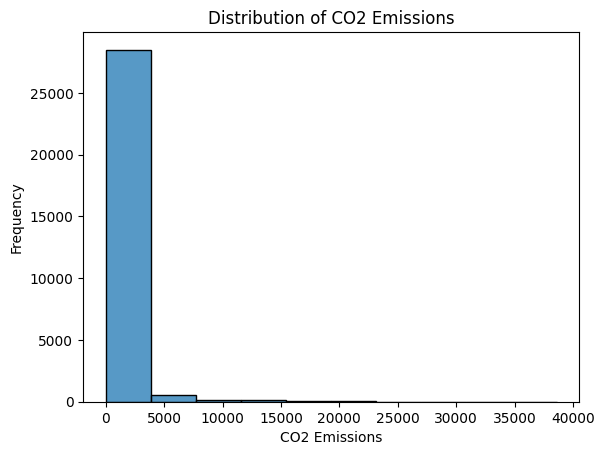

In [654]:
# Create a bar plot to visualize the distribution of CO2 emissions in the result DataFrame.
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(database_result['co2'], bins=10)
plt.title("Distribution of CO2 Emissions")
plt.xlabel("CO2 Emissions")
plt.ylabel("Frequency")
plt.show()

##### I prepared the above visualization using a bar plot to show the distribution of CO2 emissions across various countries.
##### The graph shows that the data is right-skewed meaning that few countries produce high emissions.

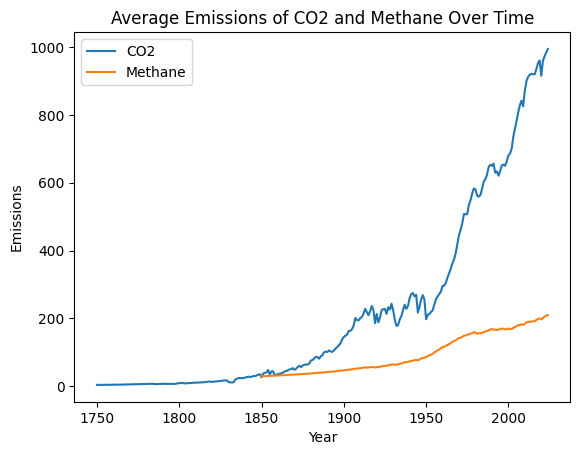

In [655]:
# Create a line plot to visualize the average CO2 and methane emissions over time.
yearly = database_result.groupby('year')[['co2', 'methane']].mean().reset_index()

plt.plot(yearly['year'], yearly['co2'], label='CO2')
plt.plot(yearly['year'], yearly['methane'], label='Methane')

plt.title("Average Emissions of CO2 and Methane Over Time")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.show()

##### The above line plot shows how both CO2 and Methane emissions have changed over time.
##### This graph helps us identify the increasing trends of the emissions.

<Axes: xlabel='Series Name'>

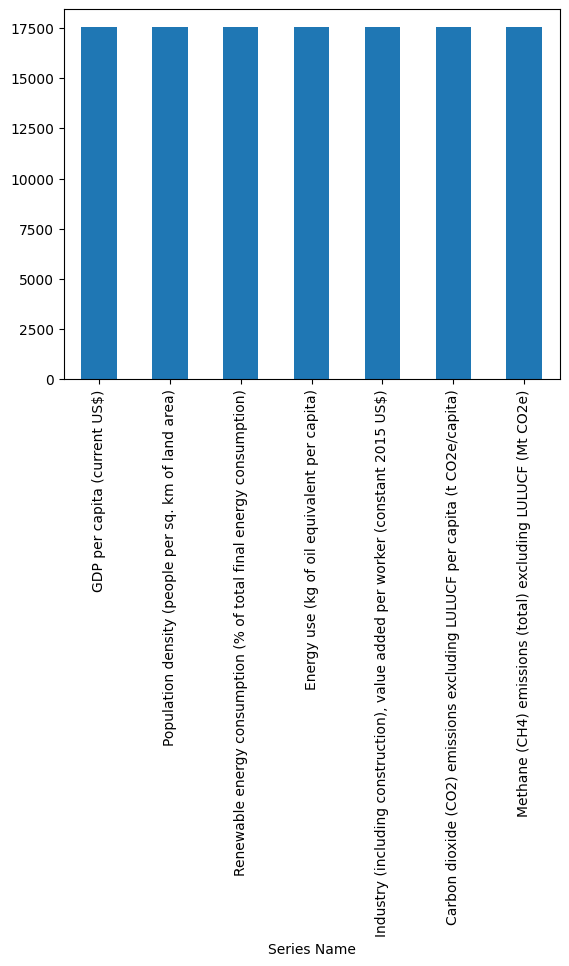

In [656]:
wdi_reshaped['Series Name'].value_counts().plot(kind='bar')

- The bar chart shows the distribution of records across different indicators in the dataset. It helps identify how frequently each indicator appears after reshaping.

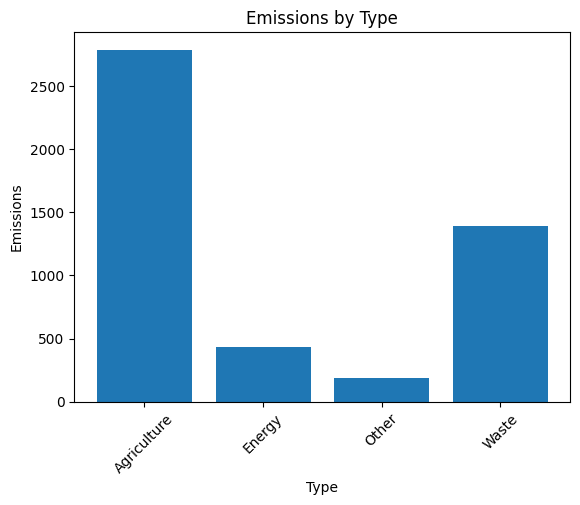

In [657]:
# Create a bar plot to visualize the emissions by type.

region_emissions = Methane_final_df.groupby('type')['emissions'].mean()

plt.bar(region_emissions.index, region_emissions.values)

plt.title("Emissions by Type")
plt.xlabel("Type")
plt.ylabel("Emissions")
plt.xticks(rotation=45)

plt.show()

- The above bar plot shows a different type of methane emissions.
- Based on this graph I can tell that agriculture causes higher emissions than the rest.

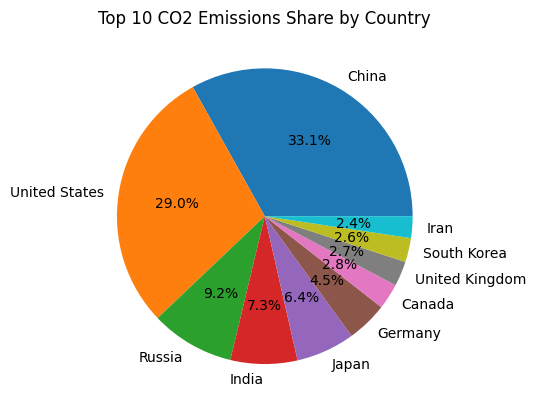

In [658]:
# Create a pie chart to visualize the share of CO2 emissions by country for the top 10 emitting countries.
top_co2 = Carbon_emissions_df.groupby('Country')['Kilotons of Co2'].sum().nlargest(10)

top_co2.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 10 CO2 Emissions Share by Country")
plt.show()

##### - The above pie chart shows emissions of the top 10 countries. This graph tells me that majority of the emsission are from these 10 countries.

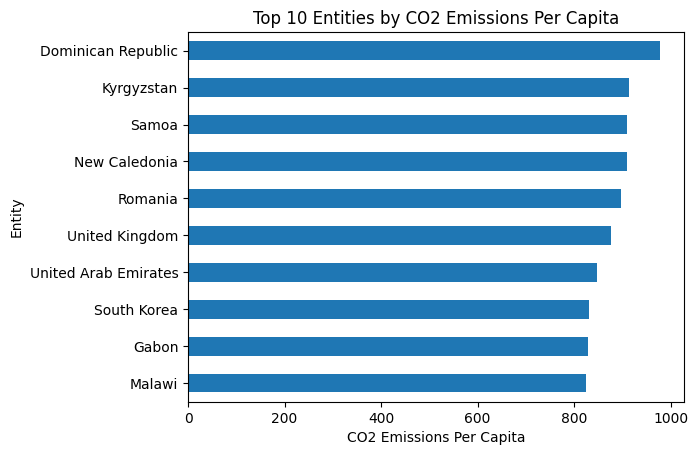

In [659]:
# Create a horizontal bar plot to visualize the top 10 entities by CO2 emissions per capita. 

#convert the 'Annual CO₂ emissions (per capita)' column to numeric.
Carbon_emissions_per_capita_df['Annual CO₂ emissions (per capita)'] = pd.to_numeric(
    Carbon_emissions_per_capita_df['Annual CO₂ emissions (per capita)'],
    errors='coerce'
)

top_pc = Carbon_emissions_per_capita_df.groupby('Entity')['Annual CO₂ emissions (per capita)'].mean().nlargest(10)

top_pc.sort_values().plot(kind='barh')
plt.title("Top 10 Entities by CO2 Emissions Per Capita")
plt.xlabel("CO2 Emissions Per Capita")
plt.ylabel("Entity")
plt.show()

##### - This graph shows the top 10 entities(countries) CO2 emissions per person. Rwanda is the highest in CO2 emissions per capita.

## 2. Data Cleaning and Transformation

- Clean up the data in database_result dataframe

In [660]:
#Check missing values in the database_result DataFrame.
database_result.isnull().sum()


country           0
year              0
co2           21027
methane       12261
population     9244
dtype: int64

In [661]:
# Drop rows where CO2 is missing, because CO2 is an essential data point for our analysis.
database_result = database_result.dropna(subset=['co2'])

# Fill population with median
database_result['population'] = database_result['population'].fillna(database_result['population'].median())
    
# Fill methane with median.
database_result['methane'] = database_result['methane'].fillna(database_result['methane'].median())

In [662]:
# Check again
database_result.isnull().sum()

country       0
year          0
co2           0
methane       0
population    0
dtype: int64

In [663]:
# Dropping missing values from the result DataFrame.
database_result.dropna(inplace=True)

In [664]:
# Checking for null values after dropping them.
database_result.isnull().sum()

country       0
year          0
co2           0
methane       0
population    0
dtype: int64

In [665]:
# Checking the data types of the columns in the database_result DataFrame.
print(database_result.dtypes)

country           str
year            int64
co2           float64
methane       float64
population    float64
dtype: object


In [666]:
# Checking the data types of the columns in the result DataFrame.
print(database_result.dtypes)

country           str
year            int64
co2           float64
methane       float64
population    float64
dtype: object


##### Check for any outliers in the database_result dataframe.

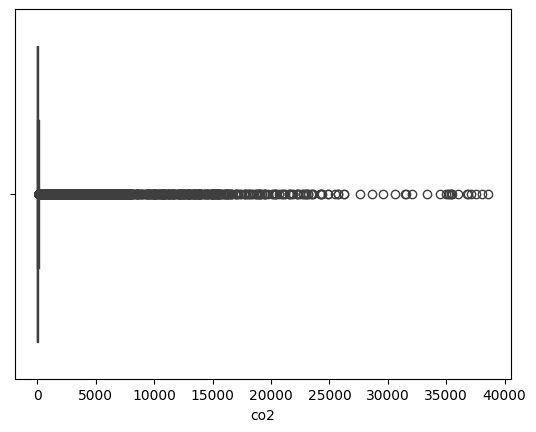

In [667]:
# Create a box plot to visualize the distribution of CO2 emissions in the database_result DataFrame.
sns.boxplot(x=database_result['co2'])
plt.show()

In [668]:
# Remove outliers from the result DataFrame based on the CO2 emissions column.
# Calculate the 99th percentile of the CO2 emissions to identify outliers and filter out 
# those values from the database_result DataFrame.
database_result = database_result[database_result['co2'] < database_result['co2'].quantile(0.99)]

- Cleanup data in the World Bank Indicater DataFrame (Reshaped)

In [669]:
# Cleanup the Year column in the wdi_reshaped DataFrame by extracting the year part. 
# The currrent Year column has a value like '2025 [YR2025]'.

wdi_reshaped['year'] = wdi_reshaped['year'].str.extract(r'(\d{4})')
wdi_reshaped.head()

,Country Name,Country Code,Series Name,Series Code,year,series_value
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,..
1,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,1960,..
2,Afghanistan,AFG,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,1960,..
3,Afghanistan,AFG,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE,1960,..
4,Afghanistan,AFG,"Industry (including construction), value added...",NV.IND.EMPL.KD,1960,..


In [670]:
# Check the data types of the columns in the wdi_reshaped DataFrame.
wdi_reshaped.info()

<class 'pandas.DataFrame'>
RangeIndex: 123222 entries, 0 to 123221
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Country Name  123024 non-null  str  
 1   Country Code  122892 non-null  str  
 2   Series Name   122892 non-null  str  
 3   Series Code   122892 non-null  str  
 4   year          123222 non-null  str  
 5   series_value  122892 non-null  str  
dtypes: str(6)
memory usage: 5.6 MB


In [671]:
# Check the data in the wdi_reshaped DataFrame after cleaning the year column.
wdi_reshaped.sample(5)

,Country Name,Country Code,Series Name,Series Code,year,series_value
85663,IDA & IBRD total,IBT,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE,2005,1013.44528900313
74397,Euro area,EMU,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,1999,7.50657160155503
27182,Pakistan,PAK,Population density (people per sq. km of land ...,EN.POP.DNST,1974,87.4526346513076
16026,Philippines,PHL,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1968,..
102956,Chad,TCD,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,2015,0.110147579596714


In [672]:
# Convert the data types of the wdi_reshaped DataFrame to appropriate types for analysis.
wdi_reshaped['year'] = wdi_reshaped['year'].astype(int)

# Convert the 'series_value' column to numeric, coercing errors to NaN. The data has some characters like '..' 
# which cannot be converted to numeric, so we will coerce those errors to NaN. This will allow us to perform 
# numerical analysis on this column.
wdi_reshaped['series_value'] = pd.to_numeric(
    wdi_reshaped['series_value'], errors='coerce'
)
wdi_reshaped.info()

<class 'pandas.DataFrame'>
RangeIndex: 123222 entries, 0 to 123221
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Country Name  123024 non-null  str    
 1   Country Code  122892 non-null  str    
 2   Series Name   122892 non-null  str    
 3   Series Code   122892 non-null  str    
 4   year          123222 non-null  int64  
 5   series_value  79364 non-null   float64
dtypes: float64(1), int64(1), str(4)
memory usage: 5.6 MB


In [675]:
# Check the data after conversion.
wdi_reshaped.sample(5)

,Country Name,Country Code,Series Name,Series Code,year,series_value
100882,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,2014,593.372222
33234,West Bank and Gaza,PSE,"Industry (including construction), value added...",NV.IND.EMPL.KD,1977,NaN
38650,Sweden,SWE,Population density (people per sq. km of land ...,EN.POP.DNST,1980,20.401967
44152,Slovak Republic,SVK,GDP per capita (current US$),NY.GDP.PCAP.CD,1983,NaN
94074,"Korea, Dem. People's Rep.",PRK,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE,2010,752.365887


In [676]:
# Check for missing values in the wdi_reshaped DataFrame after conversion.
wdi_reshaped.isna().sum()

Country Name      198
Country Code      330
Series Name       330
Series Code       330
year                0
series_value    43858
dtype: int64

- Observing lot of missing values in the series_value column of the wdi_reshaped DataFrame after conversion, we need to remove them for better analysis

In [677]:
# Removing the missing values from the wdi_reshaped DataFrame to ensure that our analysis is based on complete data.
wdi_cleaned = wdi_reshaped.dropna(subset=['series_value'])

wdi_cleaned.isna().sum()

Country Name    0
Country Code    0
Series Name     0
Series Code     0
year            0
series_value    0
dtype: int64

In [678]:
# Check the info of the wdi_cleaned DataFrame after removing missing values.
wdi_cleaned.info()

<class 'pandas.DataFrame'>
Index: 79364 entries, 14 to 121349
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  79364 non-null  str    
 1   Country Code  79364 non-null  str    
 2   Series Name   79364 non-null  str    
 3   Series Code   79364 non-null  str    
 4   year          79364 non-null  int64  
 5   series_value  79364 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 4.2 MB


In [679]:
# Check the data in the wdi_cleaned DataFrame after removing missing values.
wdi_cleaned.head()

,Country Name,Country Code,Series Name,Series Code,year,series_value
14,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,238.392477
49,Argentina,ARG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,778.251707
70,Australia,AUS,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1813.431099
77,Austria,AUT,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,939.914815
91,"Bahamas, The",BHS,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1459.253825


In [680]:
# Reset the index of the wdi_cleaned DataFrame after dropping missing values to ensure a clean index for analysis.
wdi_cleaned = wdi_cleaned.reset_index(drop=True)

In [681]:
# Check the data in the wdi_cleaned DataFrame after resetting the index.
wdi_cleaned.head()

,Country Name,Country Code,Series Name,Series Code,year,series_value
0,Algeria,DZA,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,238.392477
1,Argentina,ARG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,778.251707
2,Australia,AUS,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1813.431099
3,Austria,AUT,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,939.914815
4,"Bahamas, The",BHS,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1459.253825


In [682]:
# Rename the columns in Methane_final_df to standardize the data sets
wdi_cleaned = wdi_cleaned.rename(columns={
    'Country Name': 'country'
})

print(wdi_cleaned.columns)

Index(['country', 'Country Code', 'Series Name', 'Series Code', 'year',
       'series_value'],
      dtype='str')


##### Adding a few visualizations on the cleaned world data indicators data

In [683]:
# Picking one indicater - GDP per capita (current US$) - from the wdi_cleaned DataFrame for further analysis.
gdp_data = wdi_cleaned[
    wdi_cleaned['Series Name'] == 'GDP per capita (current US$)'
]

In [684]:
# Pick 3 countries for easier analysis and visualization.
countries = ['United States', 'India', 'China']

# Filter the gdp_data DataFrame to include only the selected countries for analysis.
gdp_data = gdp_data[gdp_data['country'].isin(countries)]

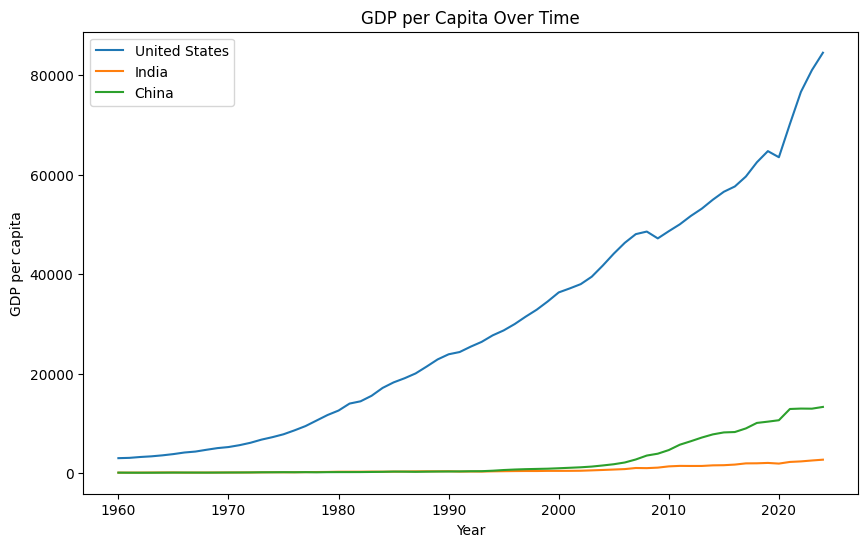

In [685]:
plt.figure(figsize=(10,6))

for country in countries:
    subset = gdp_data[gdp_data['country'] == country]
    plt.plot(subset['year'], subset['series_value'], label=country)

plt.xlabel('Year')
plt.ylabel('GDP per capita')
plt.title('GDP per Capita Over Time')
plt.legend()
plt.show()

- The line chart shows the trend of GDP per capita over time for selected countries. It highlights differences in economic growth, with some countries showing steady increases while others grow at a slower rate. This visualization helps compare economic performance across countries over time.

- I will use the above visualization to relate to emissions using the CO2 emissions series from the dataset on the same countries.

In [686]:
wdi_cleaned['Series Name'].unique()

<StringArray>
[                                                 'GDP per capita (current US$)',
                           'Population density (people per sq. km of land area)',
    'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
                    'Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)',
            'Renewable energy consumption (% of total final energy consumption)',
                                  'Energy use (kg of oil equivalent per capita)',
 'Industry (including construction), value added per worker (constant 2015 US$)']
Length: 7, dtype: str

In [687]:
# Getting the emissions data to check against the countries above.
emissions_data = wdi_cleaned[
    wdi_cleaned['Series Name'] == 'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)'
]

In [688]:
# Extract the emissions data for the selected countries to compare with the GDP data.
emissions_data = emissions_data[
    emissions_data['country'].isin(countries)
]

emissions_data.head()

,country,Country Code,Series Name,Series Code,year,series_value
3785,China,CHN,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,1.113876
3955,India,IND,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,0.389833
4343,United States,USA,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1970,22.408004
4704,China,CHN,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1971,1.087784
4874,India,IND,Carbon dioxide (CO2) emissions excluding LULUC...,EN.GHG.CO2.PC.CE.AR5,1971,0.382174


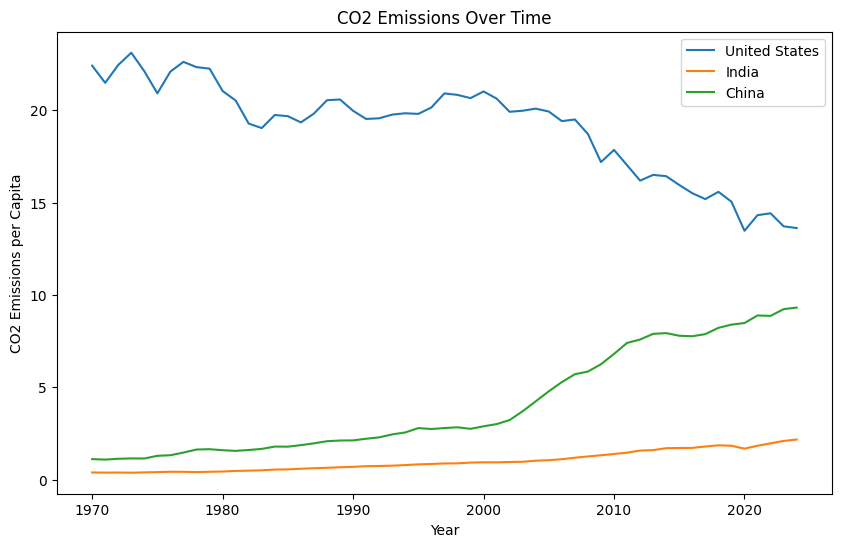

In [689]:
plt.figure(figsize=(10,6))

for country in countries:
    subset = emissions_data[emissions_data['country'] == country]
    plt.plot(subset['year'], subset['series_value'], label=country)

plt.xlabel('Year')
plt.ylabel('CO2 Emissions per Capita')
plt.title('CO2 Emissions Over Time')
plt.legend()
plt.show()

- The line chart shows how CO₂ emissions per capita changed over time for the United States, China, and India. The United States shows a declining trend in emissions despite remaining the highest among the three. In contrast, China exhibits a significant increase in emissions, particularly after 2000, reflecting rapid industrialization and economic growth. India shows a gradual increase in emissions but remains relatively low compared to the other countries. Overall, the visualization highlights how economic development stages influence environmental impact.

##### The World Bank dataset originally stored multiple indicators in a single column, with their names in the Series Name column. A pivot operation was applied to convert each unique value in Series Name into its own column using country and year as keys. This resulted in a structured dataset where each indicator became a separate feature suitable for machine learning.

In [690]:
wdi_pivot = wdi_cleaned.pivot_table(
    index=['country', 'year'],
    columns='Series Name',
    values='series_value'
).reset_index()

In [691]:
# Check the data in the wdi_pivot DataFrame after pivoting.
wdi_pivot.head()

Series Name,country,year,Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),GDP per capita (current US$),"Industry (including construction), value added per worker (constant 2015 US$)",Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e),Population density (people per sq. km of land area),Renewable energy consumption (% of total final energy consumption)
0,Afghanistan,1961,NaN,NaN,NaN,NaN,NaN,14.127046,NaN
1,Afghanistan,1962,NaN,NaN,NaN,NaN,NaN,14.418849,NaN
2,Afghanistan,1963,NaN,NaN,NaN,NaN,NaN,14.725614,NaN
3,Afghanistan,1964,NaN,NaN,NaN,NaN,NaN,15.047327,NaN
4,Afghanistan,1965,NaN,NaN,NaN,NaN,NaN,15.387222,NaN


In [692]:
# Rename the columns in the wdi_pivot DataFrame for meaningful names.
wdi_pivot = wdi_pivot.rename(columns={
    'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)': 'co2_per_capita_wdi',
    'Energy use (kg of oil equivalent per capita)': 'energy_use',
    'GDP per capita (current US$)': 'gdp_per_capita',
    'Industry (including construction), value added per worker (constant 2015 US$)': 'industry_value',
    'Methane (CH4) emissions (total) excluding LULUCF (Mt CO2e)': 'methane_wdi',
    'Population density (people per sq. km of land area)': 'population_density',
    'Renewable energy consumption (% of total final energy consumption)': 'renewable_energy'
})
wdi_pivot.head()

Series Name,country,year,co2_per_capita_wdi,energy_use,gdp_per_capita,industry_value,methane_wdi,population_density,renewable_energy
0,Afghanistan,1961,NaN,NaN,NaN,NaN,NaN,14.127046,NaN
1,Afghanistan,1962,NaN,NaN,NaN,NaN,NaN,14.418849,NaN
2,Afghanistan,1963,NaN,NaN,NaN,NaN,NaN,14.725614,NaN
3,Afghanistan,1964,NaN,NaN,NaN,NaN,NaN,15.047327,NaN
4,Afghanistan,1965,NaN,NaN,NaN,NaN,NaN,15.387222,NaN


In [693]:
wdi_pivot.info()

<class 'pandas.DataFrame'>
RangeIndex: 16564 entries, 0 to 16563
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             16564 non-null  str    
 1   year                16564 non-null  int64  
 2   co2_per_capita_wdi  13805 non-null  float64
 3   energy_use          6722 non-null   float64
 4   gdp_per_capita      14561 non-null  float64
 5   industry_value      6941 non-null   float64
 6   methane_wdi         13805 non-null  float64
 7   population_density  15296 non-null  float64
 8   renewable_energy    8234 non-null   float64
dtypes: float64(7), int64(1), str(1)
memory usage: 1.1 MB


- Cleanup data in the Methane dataframe

In [694]:
Methane_final_df.head()

,region,country,emissions,type,segment,reason,baseYear,notes
0,Africa,Algeria,257.611206,Agriculture,Total,All,2019-2021,Average based on United Nations Framework Conv...
1,Africa,Algeria,0.052000,Energy,Bioenergy,All,2022,Estimates from end-uses are for 2020 or 2021 (...
2,Africa,Algeria,130.798996,Energy,Gas pipelines and LNG facilities,Fugitive,2022,Not available
3,Africa,Algeria,69.741898,Energy,Gas pipelines and LNG facilities,Vented,2022,Not available
4,Africa,Algeria,213.987000,Energy,Onshore gas,Fugitive,2022,Not available


In [695]:
# Methane_final_df has the years in range as visible in abouve head commmand. Splitting this data into multiple rows based on the year column 
# to make it easier to merge with other dataframs

# Create an empty list to store new rows
expanded_rows = []

# Loop through each row
for _, row in Methane_final_df.iterrows():
    
    year_value = row['baseYear']
    
    # Check if it's a range like '2019-2021'
    if isinstance(year_value, str) and '-' in year_value:
        start, end = year_value.split('-')
        start = int(start)
        end = int(end)
        
        # Create a row for each year in the range
        for y in range(start, end + 1):
            new_row = row.copy()
            new_row['year'] = y
            expanded_rows.append(new_row)
    
    else:
        # If it's a single year
        new_row = row.copy()
        new_row['year'] = int(year_value)
        expanded_rows.append(new_row)

# Convert list back to DataFrame
Methane_final_df = pd.DataFrame(expanded_rows)

In [696]:
#Check the new DataFrame after expanding the year ranges.
Methane_final_df.head()

,region,country,emissions,type,segment,reason,baseYear,notes,year
0,Africa,Algeria,257.611206,Agriculture,Total,All,2019-2021,Average based on United Nations Framework Conv...,2019
0,Africa,Algeria,257.611206,Agriculture,Total,All,2019-2021,Average based on United Nations Framework Conv...,2020
0,Africa,Algeria,257.611206,Agriculture,Total,All,2019-2021,Average based on United Nations Framework Conv...,2021
1,Africa,Algeria,0.052000,Energy,Bioenergy,All,2022,Estimates from end-uses are for 2020 or 2021 (...,2022
2,Africa,Algeria,130.798996,Energy,Gas pipelines and LNG facilities,Fugitive,2022,Not available,2022


In [697]:
# Rename the columns in Methane_final_df to standardize the data sets
Methane_final_df = Methane_final_df.rename(columns={
    'country_name': 'country',
    'year': 'year'
})

print(Methane_final_df.columns)

Index(['region', 'country', 'emissions', 'type', 'segment', 'reason',
       'baseYear', 'notes', 'year'],
      dtype='str')


In [698]:
# Checking the data types of the columns in the Carbon_emissions_df DataFrame.
print(Carbon_emissions_df.dtypes)

Country                       str
Region                        str
Date                          str
Kilotons of Co2           float64
Metric Tons Per Capita    float64
dtype: object


In [699]:
# Rename the carbon_emissions_df DataFrame columns to standardize the data sets.
Carbon_emissions_df = Carbon_emissions_df.rename(columns={
    'Country': 'country',
    'Kilotons of Co2': 'co2',
    'Metric Tons Per Capita': 'co2_per_capita'
})

In [700]:
print(Carbon_emissions_df.columns)

Index(['country', 'Region', 'Date', 'co2', 'co2_per_capita'], dtype='str')


In [563]:
Carbon_emissions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5677 entries, 0 to 5676
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         5677 non-null   str    
 1   Region          5677 non-null   str    
 2   Date            5677 non-null   str    
 3   co2             5677 non-null   float64
 4   co2_per_capita  5677 non-null   float64
dtypes: float64(2), str(3)
memory usage: 221.9 KB


In [701]:
# Add a new column year to the carbon_emissions_df DataFrame by extracting the year 
# from the Date column. This will be used to join to the other data frames.

#Convert the Date column to date format.
Carbon_emissions_df['Date'] = pd.to_datetime(Carbon_emissions_df['Date'], errors='coerce')

#Extract the year from the Date column.
Carbon_emissions_df['year'] = Carbon_emissions_df['Date'].dt.year

Carbon_emissions_df[['Date', 'year']].head()

,Date,year
0,2011-01-01,2011
1,2012-01-01,2012
2,2010-01-01,2010
3,2019-01-01,2019
4,2018-01-01,2018


In [702]:
Carbon_emissions_per_capita_df = Carbon_emissions_per_capita_df.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Annual CO₂ emissions (per capita)': 'co2_per_capita'
})

In [703]:
print(Carbon_emissions_per_capita_df.columns)

Index(['country', 'year', 'co2_per_capita'], dtype='str')


In [704]:
Carbon_emissions_per_capita_df.head()

,country,year,co2_per_capita
0,Africa,1750,0.0
1,Andorra,1750,0.0
2,Asia,1750,0.0
3,Asia (excl. China and India),1750,0.0
4,Australia,1750,0.0


In [705]:
# Checking the data types of the columns in the Carbon_emissions_per_capita_df DataFrame.
print(Carbon_emissions_per_capita_df.dtypes)

country               str
year                int64
co2_per_capita    float64
dtype: object


In [718]:
# Change the data for country to be uniform accross all the datasets.
# This will help us join the datasets together.

Methane_final_df['country'] = Methane_final_df['country'].str.lower().str.strip()
Carbon_emissions_df['country'] = Carbon_emissions_df['country'].str.lower().str.strip()
Carbon_emissions_per_capita_df['country'] = Carbon_emissions_per_capita_df['country'].str.lower().str.strip()

database_result['country'] = database_result['country'].str.lower().str.strip()
wdi_pivot['country'] = wdi_pivot['country'].str.lower().str.strip()

### 1. Machine Learning Plan

#### What type of machine learning model are you planning to use?

##### I'm planning to use supervised machine learning models like regression models to predict carbon emissions. My target variable would be CO2 emissions. I will use models such as simple linear regression model, multiple linear regression model, and polinomial regression model to analyze relationships between variables like GDP, population, and emissions.

#### What are the challenges have you identified/are you anticipating in building your machine learning model?

##### Some challenges I anticipate include handling missing values in the datasets, as climate data is often incomplete for certain countries and years. Another challenge is merging multiple datasets, since they may use different country names or formats. I also expect issues with feature selection, as not all variables will be equally useful for predicting CO₂ emissions. Additionally, there is a risk of overfitting, especially when using polynomial regression models.

#### How are you planning to address these challenges?

##### To address these challenges, I will handle missing values by either filling them with appropriate statistics or removing incomplete records when necessary. I will standardize country names and formats to ensure accurate merging of datasets. For feature selection, I will choose relevant variables based on their correlation with CO₂ emissions. Also, I will evaluate model performance using a train-test split and RMSE to reduce overfitting and ensure the model generalizes well.

#### Combining the datasets to create a final dataframe on which I will apply the machine learning regression models.

In [707]:
print(database_result.columns)
print(wdi_cleaned.columns)
print(Carbon_emissions_df.columns)
print(Carbon_emissions_per_capita_df.columns)

Index(['country', 'year', 'co2', 'methane', 'population'], dtype='str')
Index(['country', 'Country Code', 'Series Name', 'Series Code', 'year',
       'series_value'],
      dtype='str')
Index(['country', 'Region', 'Date', 'co2', 'co2_per_capita', 'year'], dtype='str')
Index(['country', 'year', 'co2_per_capita'], dtype='str')


In [721]:
# Combine the database result DataFrame with methane dataframe.
final_df = database_result.merge(
    wdi_pivot,
    on=['country', 'year'],
    how='left'
)

# Merge the carbon emissions DataFrame with the final_df DataFrame.
final_df = final_df.merge(
    Carbon_emissions_df,
    on=['country', 'year'],
    how='left'
)

# Merge the carbon emissions per capita DataFrame with the final_df DataFrame.
final_df = final_df.merge(
    Carbon_emissions_per_capita_df,
    on=['country', 'year'],
    how='left'
)

# final_df = final_df.merge(
#     Methane_final_df,
#     on=['country', 'year'],
#     how='left'
# )

- Removing the methan_final_df data set because, the data set from world bank data and our world in data has already this feature

##### Perform Exploratory Data analysis on the final_df dataframe

In [722]:
# Check the info for the final Dataframe.
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29090 entries, 0 to 29089
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   country             29090 non-null  str           
 1   year                29090 non-null  int64         
 2   co2_x               29090 non-null  float64       
 3   methane             29090 non-null  float64       
 4   population          29090 non-null  float64       
 5   co2_per_capita_wdi  9206 non-null   float64       
 6   energy_use          4576 non-null   float64       
 7   gdp_per_capita      9745 non-null   float64       
 8   industry_value      4682 non-null   float64       
 9   methane_wdi         9206 non-null   float64       
 10  population_density  9895 non-null   float64       
 11  renewable_energy    5621 non-null   float64       
 12  Region              5260 non-null   str           
 13  Date                5260 non-null   datetime64[us]
 14  c

In [723]:
final_df.head()

,country,year,co2_x,methane,population,co2_per_capita_wdi,energy_use,gdp_per_capita,industry_value,methane_wdi,population_density,renewable_energy,Region,Date,co2_y,co2_per_capita_x,co2_per_capita_y
0,afghanistan,1949,0.015,7.729,7356890.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,afghanistan,1950,0.084,7.879,7776180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,afghanistan,1951,0.092,7.973,7879343.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,afghanistan,1952,0.092,8.073,7987784.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,afghanistan,1953,0.106,8.186,8096703.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [724]:
# Remove unnecessary columns from the final_df DataFrame that are not needed for our analysis.

final_df = final_df.drop(columns=[
    'co2_y',                  # duplicate source
    'co2_per_capita_y',       # too many missing values
    'Date',                   # not needed (year already exists)
    'methane_wdi',            # duplicate source
    'co2_per_capita_x',       # duplicate source
    'country'                 # Not needed for Machine Learning.
])

In [725]:
final_df.describe()


,year,co2_x,methane,population,co2_per_capita_wdi,energy_use,gdp_per_capita,industry_value,population_density,renewable_energy
count,29090.000000,29090.000000,29090.000000,2.909000e+04,9206.000000,4576.000000,9745.000000,4682.000000,9895.000000,5621.000000
mean,1947.821038,258.362130,87.025595,6.112411e+07,5.529989,2406.022664,9129.096445,33989.843263,158.131432,33.170434
std,59.179097,940.215651,285.686658,2.404831e+08,12.336606,2925.560861,17269.968079,47178.995146,472.016120,30.514024
min,1750.000000,0.000000,0.001000,1.472000e+03,0.000000,9.727288,11.801322,600.808448,0.098625,0.000000
25%,1912.000000,0.366000,2.969750,1.794480e+06,0.452363,510.010330,617.230436,6784.524821,18.032010,6.000000
50%,1962.000000,4.857500,9.414000,5.096274e+06,2.060052,1333.769633,2177.701258,15644.568190,60.697527,23.800000
75%,1994.000000,49.665000,24.875750,1.538152e+07,6.814072,3009.739040,8914.441226,36136.374819,137.288222,56.700000
max,2024.000000,9414.990000,4904.216000,3.746833e+09,202.865184,21557.475076,206780.590353,447874.029212,8241.849582,97.500000


In [726]:
# Check for missing values in the final DataFrame.
final_df.isnull().sum()

year                      0
co2_x                     0
methane                   0
population                0
co2_per_capita_wdi    19884
energy_use            24514
gdp_per_capita        19345
industry_value        24408
population_density    19195
renewable_energy      23469
Region                23830
dtype: int64

- The dataset contains missing values mainly in the World Bank features, while core variables like CO₂, methane, and population are complete. These missing values occur due to limited data availability across countries and years and will be handled using imputation during preprocessing.

In [727]:
# Rename the columns in the final_df DataFrame to standardize the data sets.
final_df.rename(columns={
    'co2_x': 'co2'
}, inplace=True)

final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29090 entries, 0 to 29089
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                29090 non-null  int64  
 1   co2                 29090 non-null  float64
 2   methane             29090 non-null  float64
 3   population          29090 non-null  float64
 4   co2_per_capita_wdi  9206 non-null   float64
 5   energy_use          4576 non-null   float64
 6   gdp_per_capita      9745 non-null   float64
 7   industry_value      4682 non-null   float64
 8   population_density  9895 non-null   float64
 9   renewable_energy    5621 non-null   float64
 10  Region              5260 non-null   str    
dtypes: float64(9), int64(1), str(1)
memory usage: 2.4 MB


In [728]:
# Check the correlation between the numerical columns in the final DataFrame to understand the relationships
#  between different variables.
final_df.corr(numeric_only=True)

,year,co2,methane,population,co2_per_capita_wdi,energy_use,gdp_per_capita,industry_value,population_density,renewable_energy
year,1.000000,0.124938,0.047399,-0.011585,-0.038562,0.020124,0.354837,0.084712,0.081705,-0.041048
co2,0.124938,1.000000,0.650283,0.447466,0.128090,0.206057,0.162127,0.051968,-0.024353,-0.141535
methane,0.047399,0.650283,1.000000,0.849977,0.080363,0.108768,0.064463,-0.043848,-0.033351,-0.065142
population,-0.011585,0.447466,0.849977,1.000000,-0.006840,-0.028744,-0.003582,-0.087630,0.006124,-0.003112
co2_per_capita_wdi,-0.038562,0.128090,0.080363,-0.006840,1.000000,0.883935,0.243106,0.543159,0.030926,-0.376399
energy_use,0.020124,0.206057,0.108768,-0.028744,0.883935,1.000000,0.620011,0.548669,0.113827,-0.433698
gdp_per_capita,0.354837,0.162127,0.064463,-0.003582,0.243106,0.620011,1.000000,0.796311,0.168563,-0.307505
industry_value,0.084712,0.051968,-0.043848,-0.087630,0.543159,0.548669,0.796311,1.000000,0.119270,-0.305961
population_density,0.081705,-0.024353,-0.033351,0.006124,0.030926,0.113827,0.168563,0.119270,1.000000,-0.163099
renewable_energy,-0.041048,-0.141535,-0.065142,-0.003112,-0.376399,-0.433698,-0.307505,-0.305961,-0.163099,1.000000


In [729]:
# Prepare the data for machine learning by splitting the final DataFrame into features (X) and target variable (y),
X = final_df.drop(columns=['co2'])
y = final_df['co2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [730]:
# Seperate numerical and categorical columns.
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: Index(['year', 'methane', 'population', 'co2_per_capita_wdi', 'energy_use',
       'gdp_per_capita', 'industry_value', 'population_density',
       'renewable_energy'],
      dtype='str')
Categorical columns: Index(['Region'], dtype='str')


/var/folders/by/7zp473_x52x3325mf_1cwxz80000gn/T/ipykernel_98725/4230482408.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns


In [731]:
# Impute missing values in the numerical columns with the median and scale the features using StandardScaler. 
# This will help to handle any missing values and ensure that the features are on a similar scale for machine learning algorithms.
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [732]:
# Impute missing values in the categorical columns with the most frequent value 
# and encode the categorical variables using OneHotEncoder.
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [733]:
# Combine the numerical and categorical pipelines into a ColumnTransformer 
# to apply the appropriate transformations to each type of data.
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [734]:
# Fit and transform the training data.
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [735]:
print(X_train_prepared.shape)
print(X_test_prepared.shape)

(23272, 14)
(5818, 14)


- The dataset was split into training and testing sets using an 80-20 ratio. The training set contains 23,272 records, while the test set contains 5,818 records. Each dataset includes 14 features used to predict CO₂ emissions, ensuring sufficient data for model training and evaluation.

In [736]:
# Train a linear regression model.
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [737]:
# Train a polynomial regression model.
poly_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin_reg', LinearRegression())
])

poly_model.fit(X_train_prepared, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly_features', ...), ('lin_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [738]:
lin_train_preds = lin_reg.predict(X_train_prepared)
lin_train_rmse = np.sqrt(mean_squared_error(y_train, lin_train_preds))
print("Linear Regression RMSE (train):", lin_train_rmse)

lin_test_preds = lin_reg.predict(X_test_prepared)
lin_test_rmse = np.sqrt(mean_squared_error(y_test, lin_test_preds))
print("Linear Regression RMSE (test):", lin_test_rmse)

Linear Regression RMSE (train): 679.0090787373664
Linear Regression RMSE (test): 692.7948549811412


In [739]:
poly_train_preds = poly_model.predict(X_train_prepared)
poly_train_rmse = np.sqrt(mean_squared_error(y_train, poly_train_preds))

print("Polynomial Regression RMSE (train):", poly_train_rmse)

poly_test_preds = poly_model.predict(X_test_prepared)
poly_test_rmse = np.sqrt(mean_squared_error(y_test, poly_test_preds))

print("Polynomial Regression RMSE (test):", poly_test_rmse)

Polynomial Regression RMSE (train): 613.6941511932791
Polynomial Regression RMSE (test): 634.0990269539647


- The Linear Regression and Polynomial Regression models were evaluated using RMSE on both training and test datasets. The Polynomial Regression model produced lower RMSE values on both the training set (613.69) and the test set (634.10) compared to the Linear Regression model. This indicates that the Polynomial model was able to better capture the underlying patterns in the data. Since the test RMSE is also lower, there is no significant overfitting observed. Therefore, the Polynomial Regression model performed better and was selected as the final model.

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

I used the lecture videos predominantly to help me with this project and I also used the course notes.

My datasets were imported from kaggle: https://www.kaggle.com

I also got data from our world in data website: 
https://ourworldindata.org/co2-and-greenhouse-gas-emissions?insight=many-countries-have-reduced-their-co2-emissions#key-insights

I imported another data set during checkpoint 3 from the world bank development indicator website
https://databank.worldbank.org/source/world-development-indicators#

In [589]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 33583 bytes to source.py
